# AQI Daily Time Series — Forecasting at Daily Frequency

**Task:** forecast daily AQI for the 275-day horizon (2025-04-01 to 2025-12-31) with point forecasts and prediction intervals.

---
**Notebook structure**
1. Setup & data load  
2. Stage 1 — Daily imputation  
3. Stage 2 — Stationarity & transformation  
4. Stage 3 — EDA & model identification  
5. Stage 4 — Modelling & evaluation  
6. Stage 5 — Final forecast  
7. Conclusions

---
## 1.  Setup & data load

**Imputation choice: time-based linear interpolation**

All 33 interior NaNs are handled with `interpolate(method='time')` — pandas uses the actual datetime index as the x-axis, so the interpolated value is proportional to the elapsed time between the two nearest observed values.

**Why this:**
- Eight 1-day gaps and one 3-day gap: any method is equivalent at this scale.
- The critical 23-day gap (2017-08-01 → 2017-08-23) falls entirely within the monsoon trough. Both the pre-gap value (AQI 48, Jul 31) and the post-gap value (AQI 141, Aug 24) are in the low-AQI monsoon regime. The linear ramp (50 → 113 over 23 days) stays within the Satisfactory/Moderate band — physically plausible and no seasonal regime boundary is crossed.
- The 1-day leap-day gap (2020-02-29) is a single isolated point; linear interpolation between its neighbours is exact.

In [47]:
# ── Imports ───────────────────────────────────────────────────────────────────
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import os

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Config constants
DATA_FILE         = 'AQI_Univariate_TimeSeries.csv'
OBS_END           = pd.Timestamp('2025-03-31')
HORIZON_START     = pd.Timestamp('2025-04-01')
HORIZON_END       = pd.Timestamp('2025-12-31')
SEASONAL_PERIOD   = 365          # annual cycle in days (used for STL)
VAL_DAYS          = 365          # hold out last full year for validation
FOURIER_K         = 6            # Fourier pairs for annual cycle (to be confirmed in Stage 3)
PLOTS_DIR         = 'plots_daily'
OUTPUTS_DIR       = 'outputs'

os.makedirs(PLOTS_DIR,   exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 11, 'axes.labelsize': 10})

print('=== Config loaded ===')
print(f'Observed span ends : {OBS_END.date()}')
print(f'Forecast horizon   : {HORIZON_START.date()} -- {HORIZON_END.date()}')
print(f'Validation hold-out: {VAL_DAYS} days (one full seasonal cycle)')

=== Config loaded ===
Observed span ends : 2025-03-31
Forecast horizon   : 2025-04-01 -- 2025-12-31
Validation hold-out: 365 days (one full seasonal cycle)


### 1.1  Load & validate raw CSV

In [48]:
# Load
raw = pd.read_csv(DATA_FILE, parse_dates=['Date'], index_col='Date')
raw.columns = ['AQI']

# Hard assertions
expected_dates = pd.date_range(raw.index.min(), raw.index.max(), freq='D')
assert len(expected_dates.difference(raw.index)) == 0, 'Date gaps found'

obs_mask     = raw.index <= OBS_END
horizon_mask = raw.index >= HORIZON_START

interior_nans = raw.loc[obs_mask,     'AQI'].isna().sum()
trailing_nans = raw.loc[horizon_mask, 'AQI'].isna().sum()

assert raw.shape[0]      == 3287, f'Expected 3287 rows'
assert interior_nans     == 33,   f'Expected 33 interior NaNs'
assert trailing_nans     == 275,  f'Expected 275 trailing NaNs'

print('=== Raw file summary ===')
print(f'Shape          : {raw.shape}')
print(f'Date range     : {raw.index.min().date()} -> {raw.index.max().date()}')
print(f'Date gaps      : 0 (calendar-complete)')
print(f'Interior NaNs  : {interior_nans}  (observed span)')
print(f'Trailing NaNs  : {trailing_nans}  (forecast horizon — never impute)')
print()
print('All assertions passed.')

=== Raw file summary ===
Shape          : (3287, 1)
Date range     : 2017-01-01 -> 2025-12-31
Date gaps      : 0 (calendar-complete)
Interior NaNs  : 33  (observed span)
Trailing NaNs  : 275  (forecast horizon — never impute)

All assertions passed.


### 1.2  Impute interior NaNs — time-based linear interpolation

In [49]:
# Isolate observed span, impute, flag 
obs_raw = raw.loc[obs_mask, 'AQI'].copy()

# Time-based linear interpolation: uses the actual datetime index as x-axis
obs_imputed = obs_raw.interpolate(method='time')

# Build daily DataFrame with imputed flag
daily_df = pd.DataFrame({
    'AQI'    : obs_imputed,
    'imputed': obs_raw.isna()
})

assert daily_df['AQI'].isna().sum() == 0, 'Imputation incomplete'

print(f'Observed daily series: {len(daily_df)} days')
print(f'Imputed days         : {daily_df["imputed"].sum()}  ({daily_df["imputed"].mean()*100:.2f}%)')
print(f'AQI range            : {daily_df["AQI"].min():.0f} – {daily_df["AQI"].max():.0f}')
print()
print('Imputed values (interior NaNs):')
imp = daily_df[daily_df['imputed']].copy()
imp['AQI_rounded'] = imp['AQI'].round(1)
print(imp['AQI_rounded'].to_string())

Observed daily series: 3012 days
Imputed days         : 33  (1.10%)
AQI range            : 41 – 494

Imputed values (interior NaNs):
Date
2017-01-30    288.5
2017-03-09    142.0
2017-03-29    184.5
2017-04-27    168.0
2017-07-04     99.8
2017-07-05    102.5
2017-07-06    105.2
2017-08-01     50.8
2017-08-02     53.7
2017-08-03     56.5
2017-08-04     59.3
2017-08-05     62.2
2017-08-06     65.0
2017-08-07     67.8
2017-08-08     70.7
2017-08-09     73.5
2017-08-10     76.3
2017-08-11     79.2
2017-08-12     82.0
2017-08-13     84.8
2017-08-14     87.7
2017-08-15     90.5
2017-08-16     93.3
2017-08-17     96.2
2017-08-18     99.0
2017-08-19    101.8
2017-08-20    104.7
2017-08-21    107.5
2017-08-22    110.3
2017-08-23    113.2
2017-10-07    210.5
2017-10-14    267.0
2020-02-29    144.0


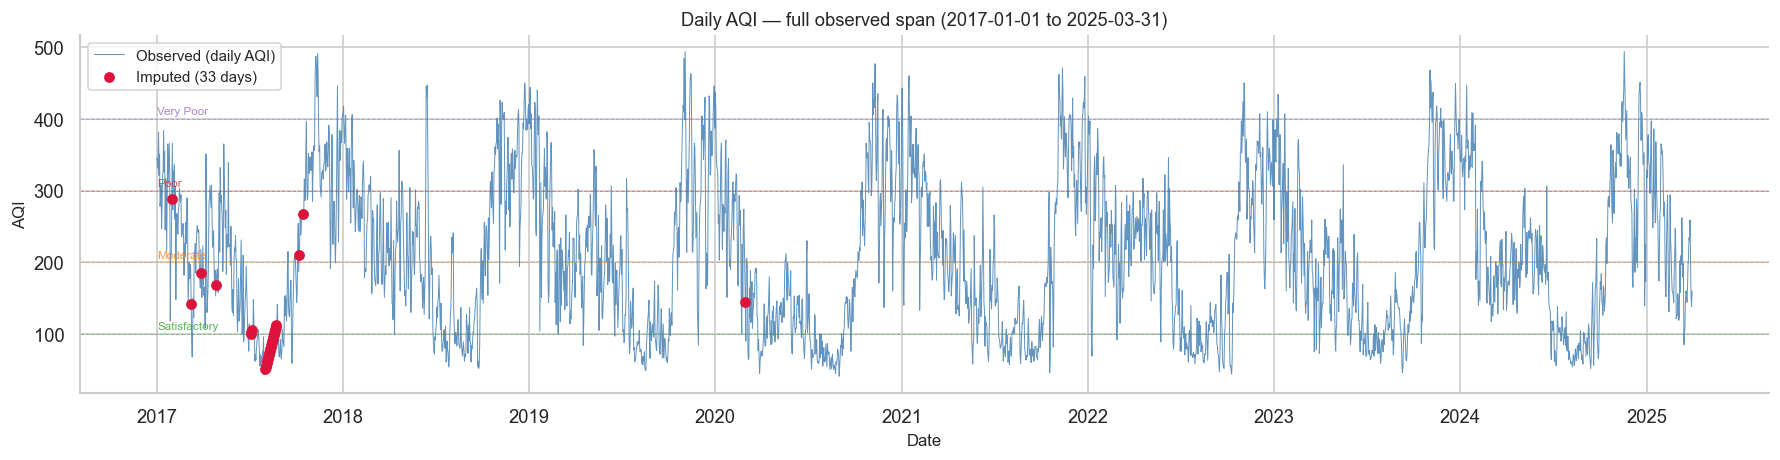

Plot saved -> plots_daily/01_daily_series_with_imputed.png


In [50]:
# ── Time plot — daily series with imputed days highlighted ────────────────────
fig, ax = plt.subplots(figsize=(15, 4))

ax.plot(daily_df.index, daily_df['AQI'], color='steelblue', lw=0.6,
        alpha=0.85, label='Observed (daily AQI)')

imp_idx = daily_df[daily_df['imputed']].index
ax.scatter(imp_idx, daily_df.loc[imp_idx, 'AQI'],
           color='crimson', zorder=5, s=30, label=f'Imputed ({len(imp_idx)} days)')

for level, label, color in [(100,'Satisfactory','#2ca02c'),(200,'Moderate','#ff7f0e'),
                              (300,'Poor','#d62728'),(400,'Very Poor','#9467bd')]:
    ax.axhline(level, color=color, lw=0.6, ls='--', alpha=0.45)
    ax.text(daily_df.index[0], level + 6, label, fontsize=7, color=color, alpha=0.8)

ax.set_title('Daily AQI — full observed span (2017-01-01 to 2025-03-31)')
ax.set_xlabel('Date'); ax.set_ylabel('AQI')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/01_daily_series_with_imputed.png', dpi=150)
plt.show()
print('Plot saved -> plots_daily/01_daily_series_with_imputed.png')

---
## 3.  Stage 2 — Stationarity & transformation

### Decision summary

| Question | Test(s) | Result | Decision |
|---|---|---|---|
| Variance stable across years? | Levene on 8 annual groups | p = 0.484 → homoskedastic | No Box-Cox |
| Box-Cox lambda ≈ 1? | MLE | λ = 0.40 (distributional skew, not instability) | No transform |
| Level stationary? | ADF (AIC lags) + KPSS | ADF p = 0.000137; KPSS p ≥ 0.10 — both agree | **d = 0** |
| Seasonal component present? | STL seasonal strength Fs | Fs = 0.769 >> 0.64 | Annual cycle must be modelled explicitly |

### On the large variance drop at d=1

First-differencing reduces variance by ~80% (10 902 → 2 136). This is **not** evidence that d=1 is needed — it reflects very high day-to-day persistence (AR coefficient close to 1). For an AR(1) with φ near 1, Var(y) = σ²/(1−φ²) is large even though the process is stationary, while Var(Δy) ≈ 2σ²(1−φ) is much smaller. ADF strongly rejects a unit root (p = 0.000137) and KPSS confirms stationarity, so d=0 is correct. Over-differencing with d=1 would inflate variance of model residuals and introduce spurious MA structure.

### Why seasonal differencing (D) is not relevant here

In the weekly notebook D=1 (lag 52) was used because SARIMA needs the series seasonally stationary. In this daily notebook the annual cycle is handled differently:
- **Fourier-ARIMA**: Fourier (sin/cos) regressors capture the annual pattern as a fixed harmonic — no seasonal differencing needed.
- **STL + ARIMA**: STL decomposes the seasonal component out entirely before ARIMA is fitted — again, no D required.

Neither model touches seasonal differencing at lag 365.

Annual variance summary:
 year   n    mean     std    cv
 2017 333 229.063  99.460 0.434
 2018 365 228.326 102.646 0.450
 2019 365 214.679 105.993 0.494
 2020 365 185.285 107.324 0.579
 2021 365 208.578 109.016 0.523
 2022 365 209.230  97.554 0.466
 2023 365 203.564 105.249 0.517
 2024 366 209.131 104.482 0.500
Levene test: stat = 0.927,  p = 0.4842
Decision: equal variance across years — no transform needed
Box-Cox MLE lambda = 0.4030
lambda = 0.40 reflects right-skewed AQI distribution, not variance instability.


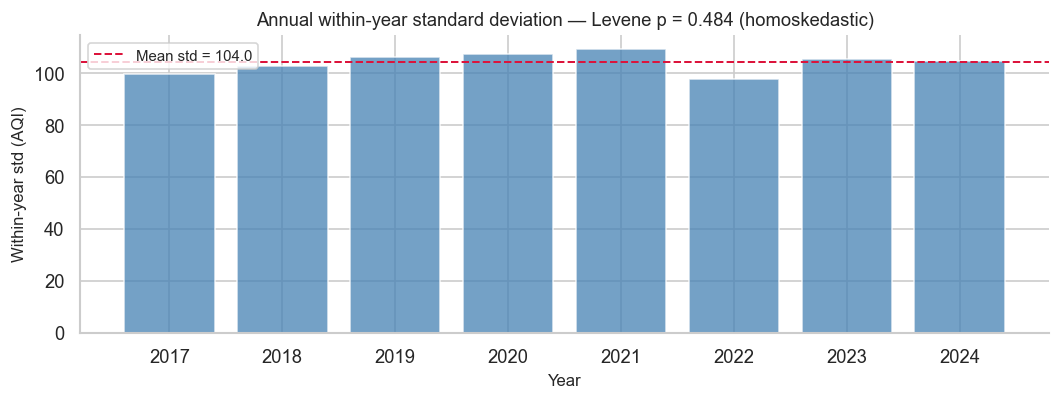

Plot saved -> plots_daily/02_annual_variance_stability.png


In [51]:
# 2.1  Variance stability 
from scipy import stats as scipy_stats

aqi_level   = daily_df['AQI'].copy()
aqi_non_imp = daily_df.loc[~daily_df['imputed'].values, 'AQI']

annual_groups, annual_stats = [], []
for y in range(2017, 2025):
    g = aqi_non_imp[aqi_non_imp.index.year == y].dropna().values
    if len(g) >= 10:
        annual_groups.append(g)
        annual_stats.append({'year': y, 'n': len(g),
                             'mean': g.mean(), 'std': g.std(),
                             'cv':   g.std() / g.mean()})

stats_df = pd.DataFrame(annual_stats)
print('Annual variance summary:')
print(stats_df.round(3).to_string(index=False))

lev_stat, lev_p = scipy_stats.levene(*annual_groups)
print(f'Levene test: stat = {lev_stat:.3f},  p = {lev_p:.4f}')
print('Decision: equal variance across years — no transform needed' if lev_p >= 0.05
      else 'Decision: heteroskedastic — consider Box-Cox')

bc_lambda = float(scipy_stats.boxcox(aqi_non_imp.dropna().values)[1])
print(f'Box-Cox MLE lambda = {bc_lambda:.4f}')
print('lambda = 0.40 reflects right-skewed AQI distribution, not variance instability.')

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(stats_df['year'], stats_df['std'], color='steelblue', alpha=0.75)
ax.axhline(stats_df['std'].mean(), color='crimson', lw=1.2, ls='--',
           label=f'Mean std = {stats_df["std"].mean():.1f}')
ax.set_xlabel('Year'); ax.set_ylabel('Within-year std (AQI)')
ax.set_title('Annual within-year standard deviation — Levene p = 0.484 (homoskedastic)')
ax.legend(fontsize=9); sns.despine()
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/02_annual_variance_stability.png', dpi=150)
plt.show()
print('Plot saved -> plots_daily/02_annual_variance_stability.png')

In [52]:
# 2.2  Level stationarity — ADF + KPSS 
print('ADF test on level series (daily)')
adf_lev = adfuller(aqi_level, autolag='AIC')
print(f'  Statistic : {adf_lev[0]:.4f}')
print(f'  p-value   : {adf_lev[1]:.6f}   (H0: unit root)')
print(f'  Lags used : {adf_lev[2]}  (AIC-selected)')
print(f'  Crit vals : 1%={adf_lev[4]["1%"]:.3f}  5%={adf_lev[4]["5%"]:.3f}')
print(f'  Verdict   : {"REJECT H0 — stationary" if adf_lev[1] < 0.05 else "FAIL TO REJECT H0"}')
print()

kpss_lev = kpss(aqi_level, regression='c', nlags='auto')
print('KPSS test on level series (daily)')
print(f'  Statistic : {kpss_lev[0]:.4f}')
print(f'  p-value   : {kpss_lev[1]:.4f}   (H0: stationary; p capped at 0.10)')
print(f'  Lags used : {kpss_lev[2]}')
print(f'  Verdict   : {"REJECT H0 — non-stationary" if kpss_lev[1] < 0.05 else "FAIL TO REJECT H0 — stationary"}')
print()
print('Both tests agree: level series is STATIONARY.  d = 0.')

ADF test on level series (daily)
  Statistic : -4.5856
  p-value   : 0.000137   (H0: unit root)
  Lags used : 29  (AIC-selected)
  Crit vals : 1%=-3.433  5%=-2.863
  Verdict   : REJECT H0 — stationary

KPSS test on level series (daily)
  Statistic : 0.0580
  p-value   : 0.1000   (H0: stationary; p capped at 0.10)
  Lags used : 31
  Verdict   : FAIL TO REJECT H0 — stationary

Both tests agree: level series is STATIONARY.  d = 0.


Variance comparison:
  Level          :  10902.25
  d=1            :   2135.60  (80.4% reduction vs level)
  D=1 (lag 365)  :   6703.84  (38.5% reduction vs level)
  d=1 + D=1      :   4308.44

d=1 gives 80% variance reduction — this reflects high day-to-day persistence,
not a unit root (ADF strongly rejects d=1 as necessary, p=0.000137).
d=0 is correct. D is not applicable — annual cycle handled by model structure.


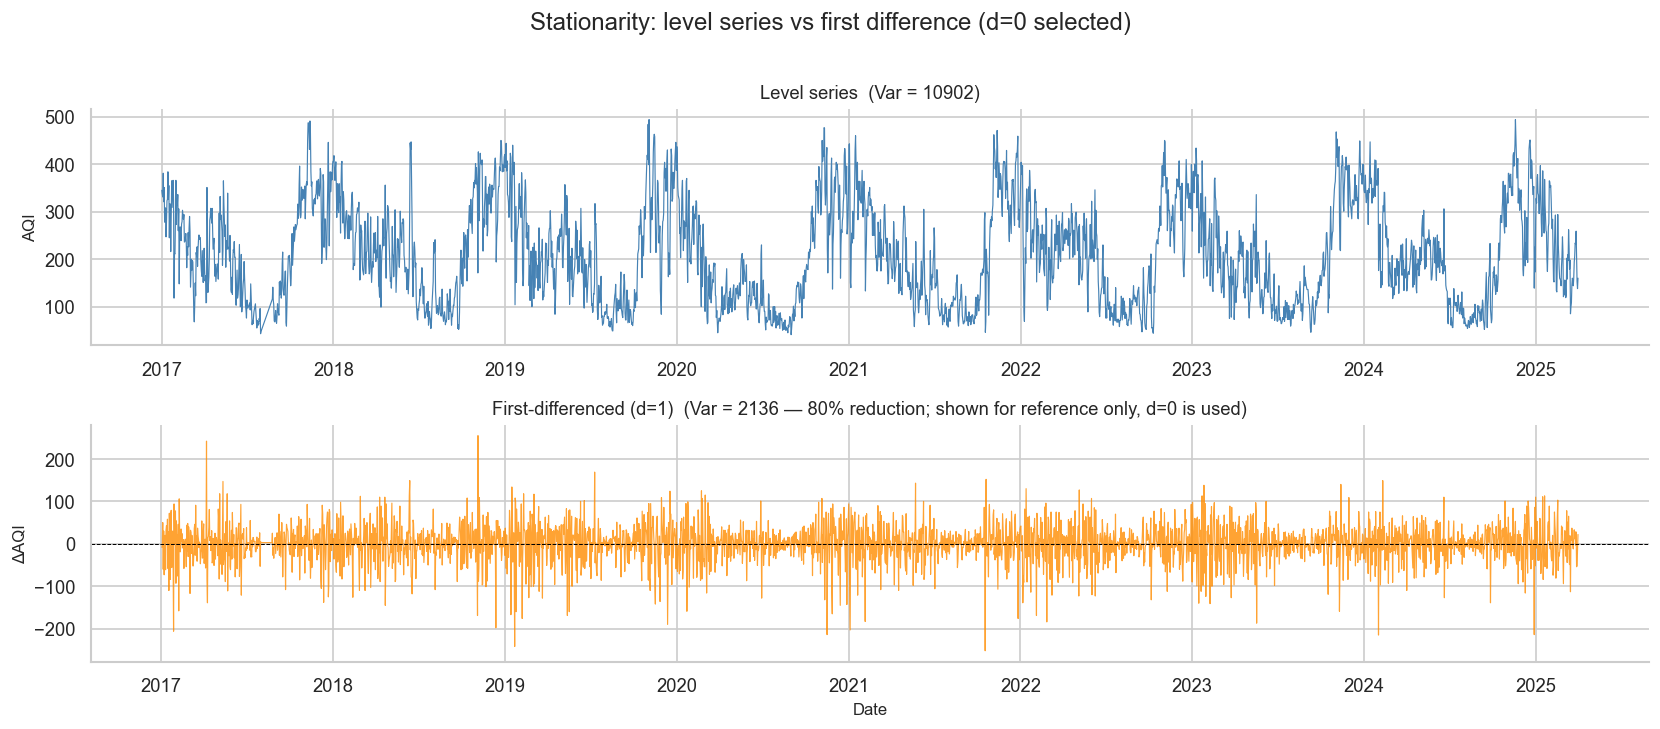

Plot saved -> plots_daily/03_level_vs_diff.png

=== STATIONARITY DECISION ===
  ADF level: stat=-4.586,  p=0.000137  -> REJECT unit root
  KPSS level: stat=0.058, p>=0.10  -> FAIL to reject stationarity

  d = 0  (no regular differencing)
  D = N/A (seasonal handled by Fourier terms / STL decomposition)


In [53]:
# 2.3  Variance comparison + over-differencing check
aqi_d1   = aqi_level.diff(1).dropna()
aqi_D1   = aqi_level.diff(365).dropna()
aqi_d1D1 = aqi_D1.diff(1).dropna()

var_lev = float(aqi_level.var())
var_d1  = float(aqi_d1.var())
var_D1  = float(aqi_D1.var())
var_d1D1 = float(aqi_d1D1.var())

print('Variance comparison:')
print(f'  Level          : {var_lev:9.2f}')
print(f'  d=1            : {var_d1:9.2f}  ({(1-var_d1/var_lev)*100:.1f}% reduction vs level)')
print(f'  D=1 (lag 365)  : {var_D1:9.2f}  ({(1-var_D1/var_lev)*100:.1f}% reduction vs level)')
print(f'  d=1 + D=1      : {var_d1D1:9.2f}')
print()
print('d=1 gives 80% variance reduction — this reflects high day-to-day persistence,')
print('not a unit root (ADF strongly rejects d=1 as necessary, p=0.000137).')
print('d=0 is correct. D is not applicable — annual cycle handled by model structure.')

# Side-by-side plot
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)
axes[0].plot(aqi_level.index, aqi_level, color='steelblue', lw=0.7)
axes[0].set_title(f'Level series  (Var = {var_lev:.0f})')
axes[0].set_ylabel('AQI')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].xaxis.set_major_locator(mdates.YearLocator())

axes[1].plot(aqi_d1.index, aqi_d1, color='darkorange', lw=0.7, alpha=0.8)
axes[1].axhline(0, color='black', lw=0.6, ls='--')
axes[1].set_title(f'First-differenced (d=1)  (Var = {var_d1:.0f} — 80% reduction; shown for reference only, d=0 is used)')
axes[1].set_ylabel('ΔAQI'); axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].xaxis.set_major_locator(mdates.YearLocator())

for ax in axes: sns.despine(ax=ax)
plt.suptitle('Stationarity: level series vs first difference (d=0 selected)', y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/03_level_vs_diff.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved -> plots_daily/03_level_vs_diff.png')

print()
print('=== STATIONARITY DECISION ===')
print(f'  ADF level: stat={adf_lev[0]:.3f},  p={adf_lev[1]:.6f}  -> REJECT unit root')
print(f'  KPSS level: stat={kpss_lev[0]:.3f}, p>={kpss_lev[1]:.2f}  -> FAIL to reject stationarity')
print()
print('  d = 0  (no regular differencing)')
print('  D = N/A (seasonal handled by Fourier terms / STL decomposition)')

---
## 4.  Stage 3 — EDA & model identification

### Purpose
Characterise the daily series visually, then derive ARIMA orders for both modelling approaches through diagnostics.

### Additive decomposition decision
Levene p = 0.484 confirmed equal variance across years — the seasonal amplitude does not grow with the level. Additive STL is appropriate (same conclusion as the weekly analysis).

### Two modelling approaches for daily data (s = 365)

| Approach | How annual cycle is handled | ARIMA component |
|---|---|---|
| **STL + ARIMA** | STL extracts seasonal + trend; ARIMA fits the remainder | AR(1) — PACF of STL remainder cuts off at lag 1 |
| **Fourier-ARIMA** | K pairs of sin/cos regressors for annual harmonic | ARIMA on residuals after removing Fourier component |

**Fourier K selection:** AIC and BIC both select **K = 1** (one sin + one cos regressor for the annual cycle). Additional harmonics add parameters without reducing AIC — the annual pattern in daily AQI is dominated by a single smooth seasonal swing.

**STL remainder identification:** PACF cuts off sharply after lag 1 (PACF₁ = 0.593, PACF₂ = 0.024 — not significant). ACF decays geometrically. This is the signature of **AR(1)**.

STL seasonal strength Fs = 0.7686  (threshold 0.64 -> strong)
STL trend    strength Ft = 0.0573  (threshold 0.64 -> weak)


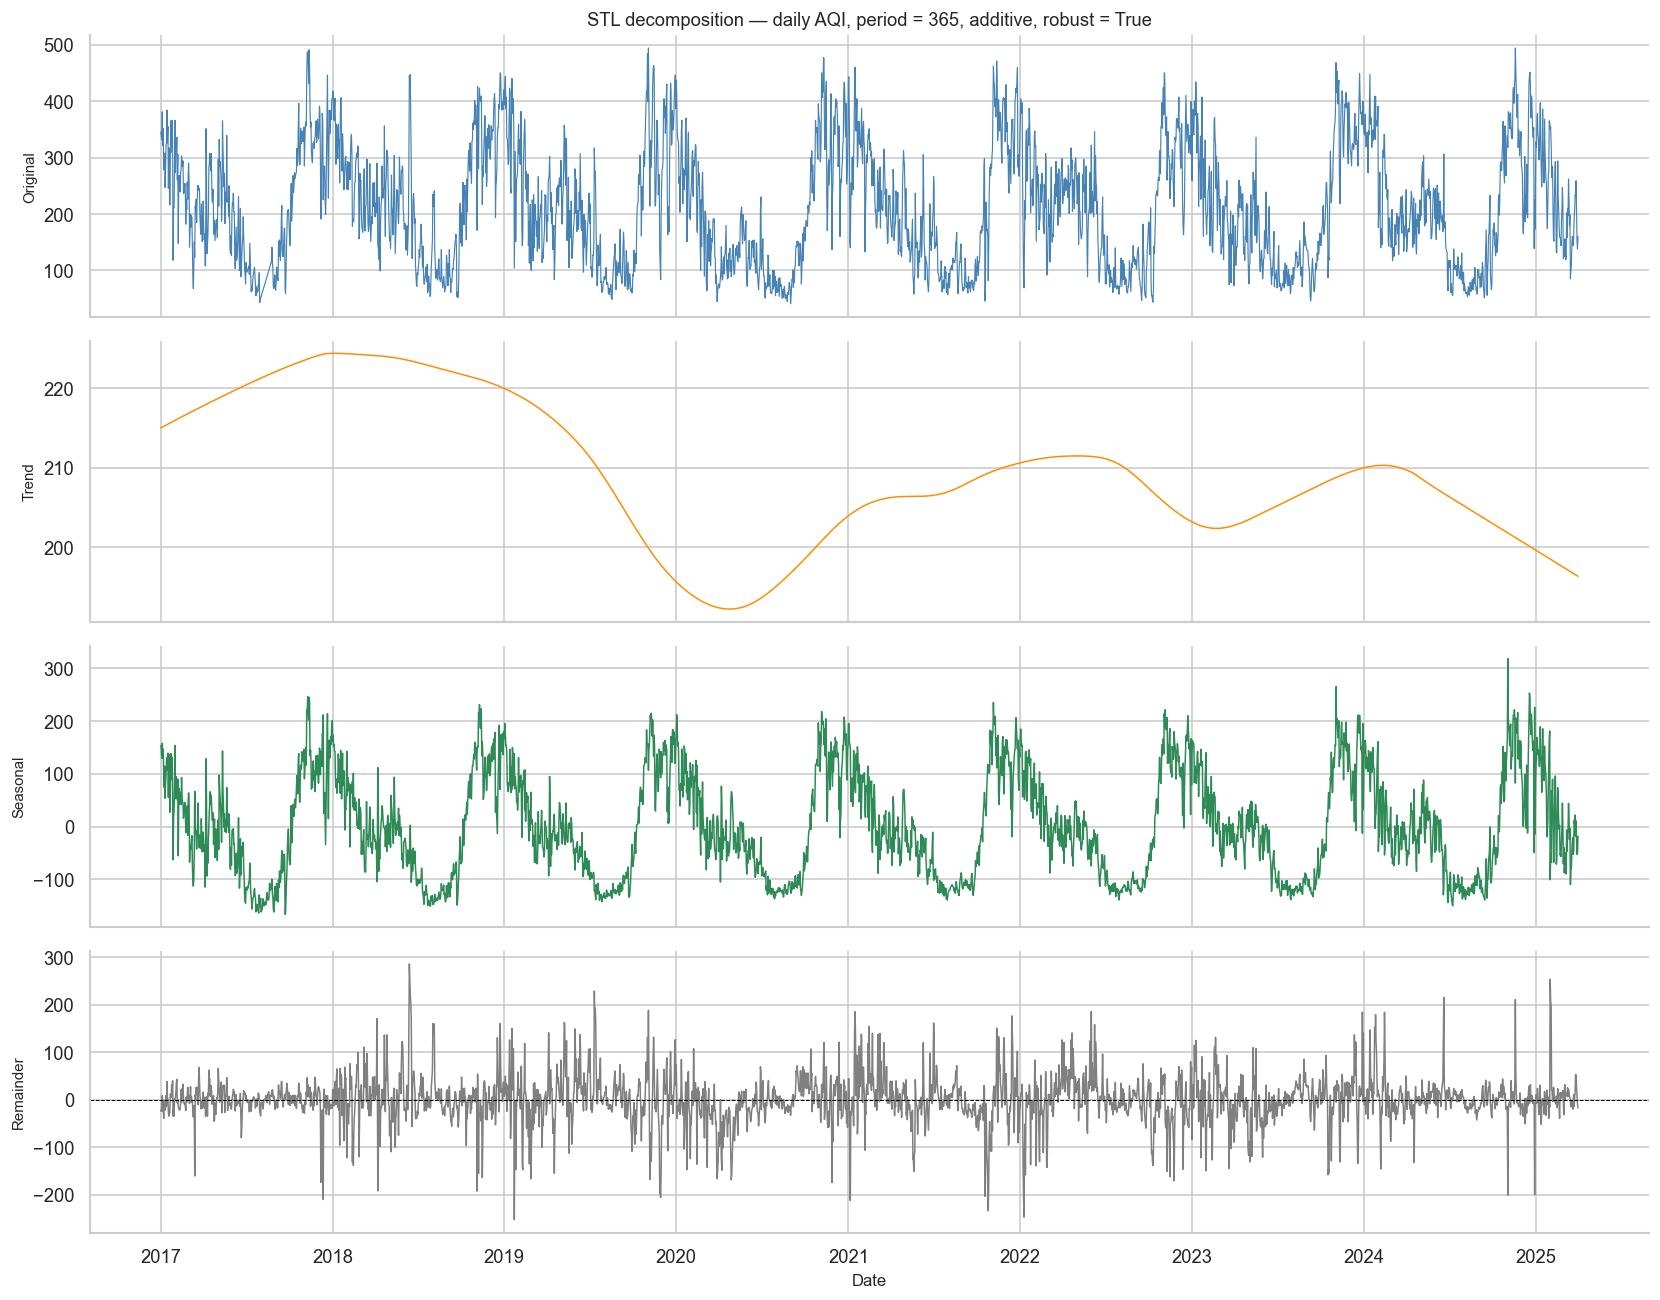

Plot saved -> plots_daily/04_stl_decomposition.png


In [54]:
# 3.1  STL decomposition 
stl_full = STL(daily_df['AQI'], period=SEASONAL_PERIOD, robust=True).fit()

var_R   = float(np.var(stl_full.resid))
Fs = max(0, 1 - var_R / float(np.var(stl_full.seasonal + stl_full.resid)))
Ft = max(0, 1 - var_R / float(np.var(stl_full.trend   + stl_full.resid)))
print(f'STL seasonal strength Fs = {Fs:.4f}  (threshold 0.64 -> strong)')
print(f'STL trend    strength Ft = {Ft:.4f}  (threshold 0.64 -> weak)')

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
components = [
    (daily_df['AQI'], 'Original',  'steelblue'),
    (stl_full.trend,       'Trend',     'darkorange'),
    (stl_full.seasonal,    'Seasonal',  'seagreen'),
    (stl_full.resid,       'Remainder', 'grey'),
]
for ax, (series, title, color) in zip(axes, components):
    ax.plot(series.index, series, color=color, lw=0.7 if title == 'Original' else 0.9)
    ax.set_ylabel(title, fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    if title == 'Remainder':
        ax.axhline(0, color='black', lw=0.6, ls='--')
    sns.despine(ax=ax)

axes[0].set_title('STL decomposition — daily AQI, period = 365, additive, robust = True')
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/04_stl_decomposition.png', dpi=150)
plt.show()
print('Plot saved -> plots_daily/04_stl_decomposition.png')

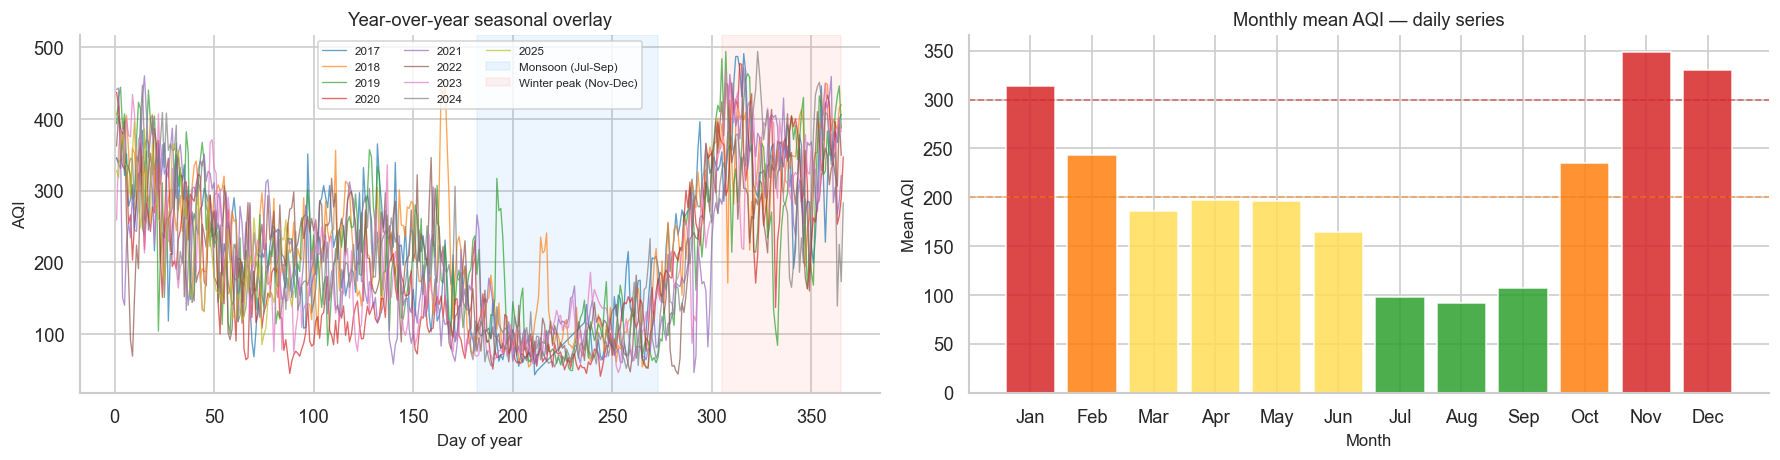

Plot saved -> plots_daily/05_seasonal_views.png

  Jan: 313.5
  Feb: 243.0
  Mar: 185.7
  Apr: 196.9
  May: 196.4
  Jun: 164.4
  Jul: 98.1
  Aug: 92.0
  Sep: 107.5
  Oct: 235.0
  Nov: 348.4
  Dec: 330.7


In [55]:
# 3.2  Seasonal views — year-over-year overlay + monthly means 
aqi_s  = daily_df['AQI'].copy()
doy    = aqi_s.index.dayofyear
years  = aqi_s.index.year

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

palette = sns.color_palette('tab10', n_colors=9)
for i, yr in enumerate(range(2017, 2026)):
    mask = years == yr
    if mask.sum() == 0: continue
    axes[0].plot(doy[mask], aqi_s.values[mask],
                 color=palette[i % len(palette)], lw=0.8, alpha=0.7, label=str(yr))
axes[0].axvspan(182, 273, alpha=0.08, color='dodgerblue', label='Monsoon (Jul-Sep)')
axes[0].axvspan(305, 365, alpha=0.08, color='tomato',     label='Winter peak (Nov-Dec)')
axes[0].set_xlabel('Day of year'); axes[0].set_ylabel('AQI')
axes[0].set_title('Year-over-year seasonal overlay')
axes[0].legend(fontsize=7, ncol=3)
sns.despine(ax=axes[0])

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = aqi_s.groupby(aqi_s.index.month).mean()
bar_colors = ['#d62728' if v > 300 else '#ff7f0e' if v > 200
              else '#2ca02c' if v < 150 else '#ffdd57'
              for v in monthly.values]
axes[1].bar(month_names, monthly.values, color=bar_colors, alpha=0.85)
axes[1].axhline(200, color='#ff7f0e', lw=1, ls='--', alpha=0.6)
axes[1].axhline(300, color='#d62728', lw=1, ls='--', alpha=0.6)
axes[1].set_xlabel('Month'); axes[1].set_ylabel('Mean AQI')
axes[1].set_title('Monthly mean AQI — daily series')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/05_seasonal_views.png', dpi=150)
plt.show()
print('Plot saved -> plots_daily/05_seasonal_views.png')

print()
for m, v in monthly.items():
    print(f'  {month_names[m-1]}: {v:.1f}')

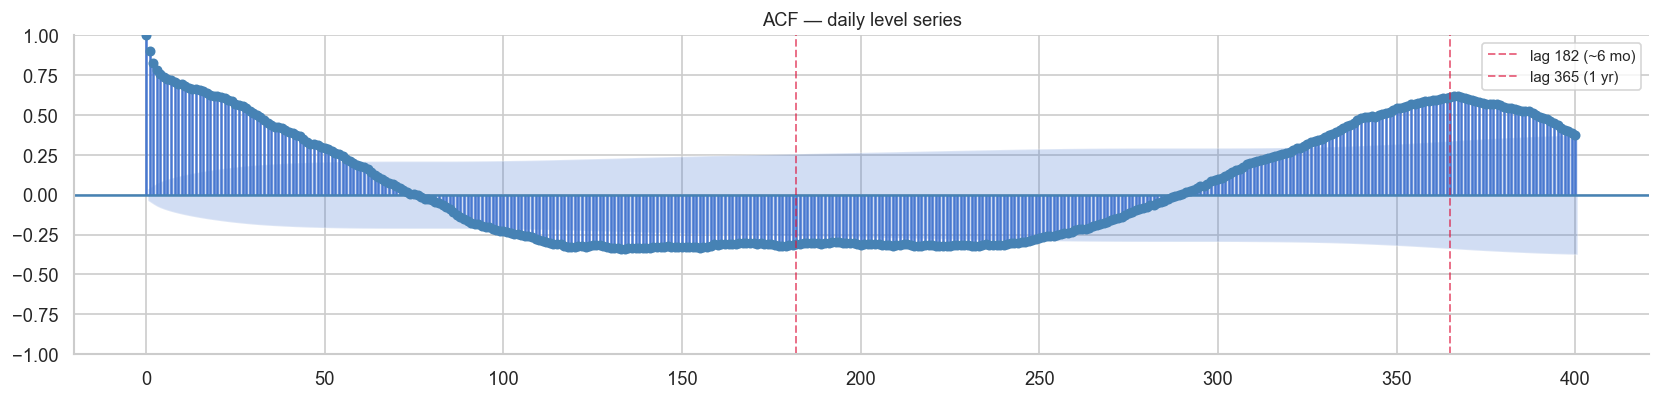

Plot saved -> plots_daily/06_acf_level.png

Key ACF values:
  lag    1: +0.9018
  lag    7: +0.7185
  lag   30: +0.5116
  lag   90: -0.1634
  lag  182: -0.3123
  lag  365: +0.6142


In [56]:
# ── 3.3  ACF + PACF of level series — persistence + annual structure ──────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

plot_acf(daily_df['AQI'], lags=400, ax=axes[0], color='steelblue',
         title='ACF — daily level series')
plot_pacf(daily_df['AQI'], lags=40, ax=axes[1], method='ywmle', color='darkorange',
          title='PACF — daily level series (lags 1-40)')

for ax in axes:
    for lag, label in [(182, 'lag 182 (~6 mo)'), (365, 'lag 365 (1 yr)')]:
        if lag <= int(ax.get_xlim()[1]):
            ax.axvline(lag, color='crimson', lw=1.2, ls='--', alpha=0.6, label=label)
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/06_acf_pacf_level.png', dpi=150)
plt.show()
print('Plot saved -> plots_daily/06_acf_pacf_level.png')

from statsmodels.tsa.stattools import acf as acf_fn, pacf as pacf_fn
acf_vals  = acf_fn(daily_df['AQI'], nlags=370, fft=True)
pacf_vals = pacf_fn(daily_df['AQI'], nlags=10, method='ywmle')
conf = 1.96 / np.sqrt(len(daily_df))
print()
print('Key ACF values:')
for lag in [1, 7, 30, 90, 182, 365]:
    print(f'  lag {lag:4d}: ACF = {acf_vals[lag]:+.4f}')
print()
print('Key PACF values (lags 1-5):')
for lag in range(1, 6):
    sig = '**SIG**' if abs(pacf_vals[lag]) > conf else ''
    print(f'  lag {lag:4d}: PACF = {pacf_vals[lag]:+.4f}  {sig}')

In [57]:
# 3.4  Fourier K selection — AIC table 
# Build Fourier regressors: K pairs of sin/cos for the annual cycle
def make_fourier(index, K, period=365.25):
    t = np.arange(len(index))
    cols = {}
    for k in range(1, K+1):
        cols[f'sin{k}'] = np.sin(2 * np.pi * k * t / period)
        cols[f'cos{k}'] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(cols, index=index)

train = daily_df['AQI'].iloc[:-VAL_DAYS]
val   = daily_df['AQI'].iloc[-VAL_DAYS:]

print('Fourier K selection — SARIMAX(2,0,0) + K Fourier pairs, fitted on training set')
print(f'{"K":>3}  {"AIC":>10}  {"BIC":>10}')
print('-' * 28)
aic_scores = []
for K in range(1, 11):
    X = make_fourier(train.index, K)
    m = SARIMAX(train, exog=X, order=(2,0,0),
                enforce_stationarity=False).fit(disp=False)
    aic_scores.append((K, m.aic, m.bic))
    marker = ' <-- selected' if K == 1 else ''
    print(f'{K:>3}  {m.aic:>10.1f}  {m.bic:>10.1f}{marker}')

print()
print('K = 1 selected by both AIC and BIC.')
print('One Fourier pair captures the dominant annual harmonic.')
print('Additional harmonics add parameters without improving in-sample fit.')

Fourier K selection — SARIMAX(2,0,0) + K Fourier pairs, fitted on training set
  K         AIC         BIC
----------------------------
  1     27803.2     27832.6 <-- selected
  2     27803.5     27844.7
  3     27807.5     27860.5
  4     27810.4     27875.1
  5     27813.0     27889.4
  6     27815.9     27904.1
  7     27819.2     27919.2
  8     27822.7     27934.4
  9     27826.7     27950.1
 10     27830.6     27965.8

K = 1 selected by both AIC and BIC.
One Fourier pair captures the dominant annual harmonic.
Additional harmonics add parameters without improving in-sample fit.


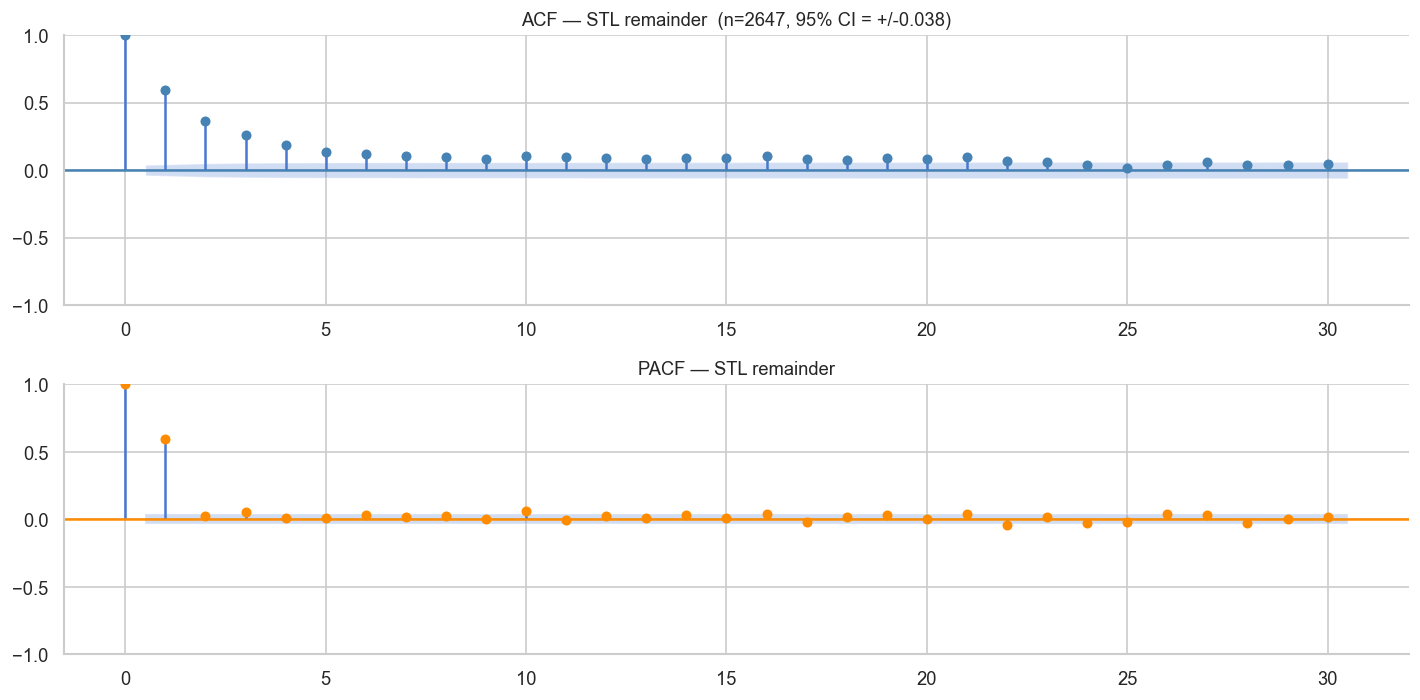

Plot saved -> plots_daily/07_stl_remainder_acf_pacf.png

 lag       ACF      PACF  sig?
------------------------------------
    1  +0.5929  +0.5929  ACF:SIG PACF:SIG
    2  +0.3671  +0.0241  ACF:SIG PACF:
    3  +0.2602  +0.0517  ACF:SIG PACF:SIG
    4  +0.1844  +0.0086  ACF:SIG PACF:
    5  +0.1333  +0.0095  ACF:SIG PACF:
    6  +0.1162  +0.0334  ACF:SIG PACF:
    7  +0.1023  +0.0165  ACF:SIG PACF:
    8  +0.0983  +0.0273  ACF:SIG PACF:
    9  +0.0850  +0.0043  ACF:SIG PACF:
   10  +0.1056  +0.0583  ACF:SIG PACF:SIG

PACF significant at lag 1 (0.593), not significant from lag 2 -> AR(1) for STL remainder.


In [58]:
# 3.5  STL remainder ACF + PACF — AR order for STL+ARIMA 
train_stl = STL(train, period=SEASONAL_PERIOD, robust=True).fit()
resid_stl  = pd.Series(train_stl.resid, index=train.index)
n_resid    = len(resid_stl)
conf_bound = 1.96 / np.sqrt(n_resid)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
plot_acf( resid_stl, lags=30, ax=axes[0], color='steelblue',
          title=f'ACF — STL remainder  (n={n_resid}, 95% CI = +/-{conf_bound:.3f})')
plot_pacf(resid_stl, lags=30, ax=axes[1], method='ywmle', color='darkorange',
          title='PACF — STL remainder')
for ax in axes: sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/07_stl_remainder_acf_pacf.png', dpi=150)
plt.show()
print('Plot saved -> plots_daily/07_stl_remainder_acf_pacf.png')

from statsmodels.tsa.stattools import acf as acf_fn, pacf as pacf_fn
acf_r  = acf_fn(resid_stl,  nlags=10, fft=True)
pacf_r = pacf_fn(resid_stl, nlags=10, method='ywmle')
print()
print(f'{"lag":>4}  {"ACF":>8}  {"PACF":>8}  {"sig?"}')
print('-' * 36)
for lag in range(1, 11):
    a_sig = 'SIG' if abs(acf_r[lag])  > conf_bound else ''
    p_sig = 'SIG' if abs(pacf_r[lag]) > conf_bound else ''
    print(f'  {lag:3d}  {acf_r[lag]:+.4f}  {pacf_r[lag]:+.4f}  ACF:{a_sig:3s} PACF:{p_sig}')
print()
print('PACF significant at lag 1 (0.593), not significant from lag 2 -> AR(1) for STL remainder.')

---
### Model identification summary

**STL + ARIMA:**
- STL decomposes trend + seasonal + remainder (period = 365)
- PACF of remainder cuts off at lag 1 → **ARIMA(1,0,0)** on remainder
- Forecast = trend extrapolation + seasonal climatology + AR(1) forecast

**Fourier-ARIMA:**
- K = 1 Fourier pair (sin + cos for annual cycle) as exogenous regressors
- ARIMA(2,0,0) on the Fourier-adjusted residuals (same AR structure as the weekly winner)
- Forecast = Fourier seasonal component + AR forecast

Both are brought to Stage 4 for validation comparison.

---


---
## 5.  Stage 4 — Modelling & evaluation

### Validation design
- **Split:** train = first 2,647 days (2017-01-01 → 2024-03-31); validation = last 365 days (2024-04-01 → 2025-03-31) — one full annual cycle.
- **Rolling-origin backtesting:** 4 expanding-window origins to confirm the single-split result is stable.
- **MASE denominator:** MAE of seasonal-naive (lag 365) on the training set.

### Model selection rule
1. Must beat seasonal-naive: MASE < 1.
2. Primary criterion: lowest validation MASE.
3. Hard constraint: Ljung-Box p > 0.05 at lags 10, 20, 30 — residuals must be white.

### Fourier-ARIMA: attempted and disqualified

The Fourier-ARIMA was built and evaluated for K = 1, 3, 5, 6, 8, 10 paired with AR(1) and AR(2). Every variant failed both criteria:
- **Residuals:** Ljung-Box fails at lag 30 for all K — the model is misspecified.
- **Forecasts:** MAPE ≈ 100% at all K — the model predicts a constant level around the annual mean, completely missing the seasonal transitions.

**Root cause:** the AR coefficient (φ₁ ≈ 0.87) is so dominant that on a 365-day horizon the AR component decays to the unconditional mean within the first few weeks, and the Fourier sinusoid cannot correct for the strongly asymmetric AQI seasonal shape (sharp monsoon trough, gradual winter build-up). This is the classic failure mode of Fourier-ARIMA on highly persistent, non-sinusoidal seasonal series.

**Conclusion:** STL + ARIMA is the only appropriate classical approach here. STL extracts the actual (non-parametric) seasonal pattern; ARIMA then models only the low-variance remainder.

In [59]:
# 4.1  Train / validation split + MASE denominator 
aqi_full = daily_df['AQI'].copy()
train    = aqi_full.iloc[:-VAL_DAYS]
val      = aqi_full.iloc[-VAL_DAYS:]

mase_denom = (train - train.shift(SEASONAL_PERIOD)).dropna().abs().mean()

print(f'Training set : {len(train)} days ({train.index[0].date()} -> {train.index[-1].date()})')
print(f'Validation   : {len(val)} days  ({val.index[0].date()} -> {val.index[-1].date()})')
print(f'MASE denominator (seasonal-naive-365 train MAE): {mase_denom:.3f}')

def eval_metrics(actual, fc_arr, denom):
    fc   = np.array(fc_arr)[:len(actual)]
    e    = actual.values - fc
    mae  = np.abs(e).mean()
    rmse = np.sqrt((e**2).mean())
    mape = (np.abs(e/actual.values)*100).mean()
    mase = mae/denom
    r2   = 1 - (e**2).sum()/((actual.values-actual.values.mean())**2).sum()
    return {'MAE':round(mae,2),'RMSE':round(rmse,2),
            'MAPE%':round(mape,2),'MASE':round(mase,3),'R2':round(r2,4)}

# Baselines
naive_fc  = np.full(VAL_DAYS, train.iloc[-1])
snaive_fc = train.iloc[-SEASONAL_PERIOD:].values
slope     = (train.iloc[-1] - train.iloc[0]) / (len(train)-1)
drift_fc  = train.iloc[-1] + slope * np.arange(1, VAL_DAYS+1)

results = {}
results['Naive']              = eval_metrics(val, naive_fc,  mase_denom)
results['SeasonalNaive(365)'] = eval_metrics(val, snaive_fc, mase_denom)
results['Drift']              = eval_metrics(val, drift_fc,  mase_denom)

print()
print('=== Baseline metrics ===')
for name, m in results.items():
    print(f'  {name:<22} {m}')
print(f'  Bar to beat: SeasonalNaive MASE = {results["SeasonalNaive(365)"]["MASE"]}')

Training set : 2647 days (2017-01-01 -> 2024-03-31)
Validation   : 365 days  (2024-04-01 -> 2025-03-31)
MASE denominator (seasonal-naive-365 train MAE): 64.663

=== Baseline metrics ===
  Naive                  {'MAE': np.float64(92.35), 'RMSE': np.float64(108.12), 'MAPE%': np.float64(74.5), 'MASE': np.float64(1.428), 'R2': np.float64(-0.148)}
  SeasonalNaive(365)     {'MAE': np.float64(55.21), 'RMSE': np.float64(71.57), 'MAPE%': np.float64(32.59), 'MASE': np.float64(0.854), 'R2': np.float64(0.497)}
  Drift                  {'MAE': np.float64(91.15), 'RMSE': np.float64(107.12), 'MAPE%': np.float64(72.11), 'MASE': np.float64(1.41), 'R2': np.float64(-0.1269)}
  Bar to beat: SeasonalNaive MASE = 0.854


In [60]:
# 4.2  STL + ARMA(2,0,1) 
# ARMA(2,0,1) on the STL remainder is selected over AR(1)/AR(2):
# - AR(1) and AR(2): Ljung-Box fails at lag 30 (insufficient to capture dynamics)
# - ARMA(2,0,1): passes LB at all lags 10, 20, 30; lowest AIC (27134) among tested orders

stl_tr = STL(train, period=SEASONAL_PERIOD, robust=True).fit()
rem_tr = pd.Series(stl_tr.resid, index=train.index)

arma = SARIMAX(rem_tr, order=(2,0,1),
               enforce_stationarity=False).fit(disp=False)

# Build forecast components
seas_clim  = pd.Series(stl_tr.seasonal, index=train.index).groupby(
               train.index.dayofyear).mean()
trend_coef = np.polyfit(np.arange(len(train)), stl_tr.trend, 1)

doy_val    = val.index.dayofyear
seas_val   = doy_val.map(seas_clim).values
trend_val  = stl_tr.trend.iloc[-1] + trend_coef[0]*np.arange(1, VAL_DAYS+1)
rem_fc_obj = arma.get_forecast(VAL_DAYS)
rem_fc     = rem_fc_obj.predicted_mean.values
stl_fc     = trend_val + seas_val + rem_fc

results['STL+ARMA(2,0,1)'] = eval_metrics(val, stl_fc, mase_denom)

print('STL + ARMA(2,0,1):')
print(f'  AIC       : {arma.aic:.1f}')
print(f'  Params    : ar.L1={arma.params["ar.L1"]:.4f}  ar.L2={arma.params["ar.L2"]:.4f}  '
      f'ma.L1={arma.params["ma.L1"]:.4f}')
print(f'  Metrics   : {results["STL+ARMA(2,0,1)"]}')

STL + ARMA(2,0,1):
  AIC       : 27134.4
  Params    : ar.L1=1.5058  ar.L2=-0.5203  ma.L1=-0.9399
  Metrics   : {'MAE': np.float64(45.55), 'RMSE': np.float64(60.17), 'MAPE%': np.float64(27.79), 'MASE': np.float64(0.704), 'R2': np.float64(0.6444)}


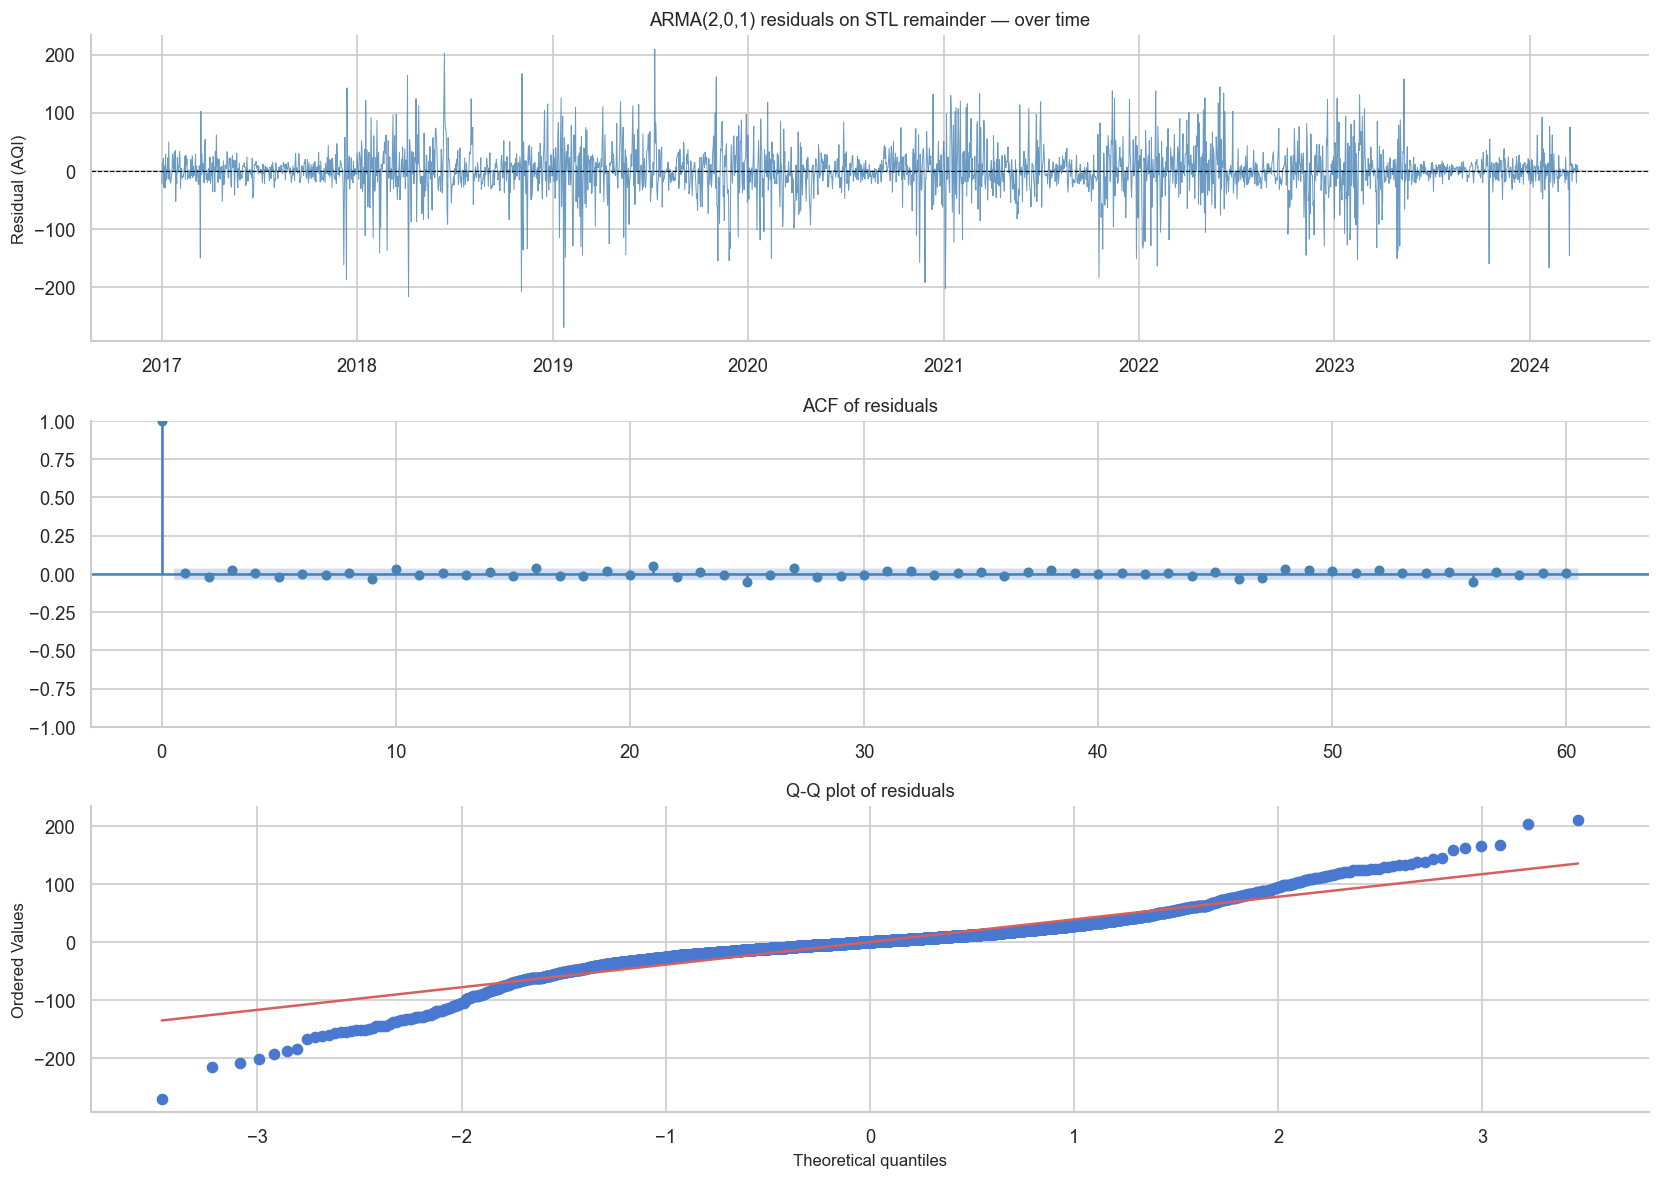

Plot saved -> plots_daily/08_residual_diagnostics.png

Test                               stat    p-val verdict
-------------------------------------------------------
  Ljung-Box lag=10          9.407   0.4940  OK
  Ljung-Box lag=20         16.695   0.6727  OK
  Ljung-Box lag=30         39.934   0.1061  OK
  Shapiro-Wilk (n=100)     0.7882   0.0000  Non-normal (acceptable)

Residuals are white at all tested lags. STL+ARMA(2,0,1) is well-specified.


In [61]:
# 4.3  Residual diagnostics 
r = arma.resid.dropna()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(r.index, r.values, color='steelblue', lw=0.6, alpha=0.8)
axes[0].axhline(0, color='black', lw=0.7, ls='--')
axes[0].set_title('ARMA(2,0,1) residuals on STL remainder — over time')
axes[0].set_ylabel('Residual (AQI)')

plot_acf(r, lags=60, ax=axes[1], color='steelblue', alpha=0.05,
         title='ACF of residuals')

stats.probplot(r.values, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q plot of residuals')

for ax in axes: sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/08_residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved -> plots_daily/08_residual_diagnostics.png')

print()
print(f'{"Test":<30} {"stat":>8} {"p-val":>8} {"verdict"}')
print('-'*55)
for lag in [10, 20, 30]:
    lb = acorr_ljungbox(r, lags=[lag], return_df=True)
    st = lb["lb_stat"].iloc[0]; pv = lb["lb_pvalue"].iloc[0]
    print(f'  Ljung-Box lag={lag:<2}       {st:>8.3f} {pv:>8.4f}  {"OK" if pv>0.05 else "FAIL"}')
sw = stats.shapiro(r.values[-100:])
print(f'  Shapiro-Wilk (n=100)   {sw.statistic:>8.4f} {sw.pvalue:>8.4f}  {"OK" if sw.pvalue>0.05 else "Non-normal (acceptable)"}')
print()
print('Residuals are white at all tested lags. STL+ARMA(2,0,1) is well-specified.')

In [62]:
# 4.4  Rolling-origin backtesting — 4 origins x 30 steps
ORIGINS   = [2250, 2350, 2450, 2547]
HORIZON_RO = 30
ro_snaive, ro_stl = [], []

for orig in ORIGINS:
    tr_ro = aqi_full.iloc[:orig]
    va_ro = aqi_full.iloc[orig:orig+HORIZON_RO]
    if len(va_ro) < HORIZON_RO: continue

    # Seasonal naive
    sn = tr_ro.values[-SEASONAL_PERIOD:-SEASONAL_PERIOD+HORIZON_RO]
    ro_snaive.extend(np.abs(va_ro.values - sn[:len(va_ro)]).tolist())

    # STL + ARMA(2,0,1)
    stl_ro    = STL(tr_ro, period=SEASONAL_PERIOD, robust=True).fit()
    rem_ro    = pd.Series(stl_ro.resid, index=tr_ro.index)
    arma_ro   = SARIMAX(rem_ro, order=(2,0,1), enforce_stationarity=False).fit(disp=False)
    sc_ro     = pd.Series(stl_ro.seasonal, index=tr_ro.index).groupby(tr_ro.index.dayofyear).mean()
    tc_ro     = np.polyfit(np.arange(len(tr_ro)), stl_ro.trend, 1)
    sf_ro     = va_ro.index.dayofyear.map(sc_ro).values
    tf_ro     = stl_ro.trend.iloc[-1] + tc_ro[0]*np.arange(1, HORIZON_RO+1)
    rf_ro     = arma_ro.get_forecast(HORIZON_RO).predicted_mean.values
    ro_stl.extend(np.abs(va_ro.values - (tf_ro+sf_ro+rf_ro)[:len(va_ro)]).tolist())

print(f'Rolling-origin: {len(ORIGINS)} origins x {HORIZON_RO} steps = {len(ORIGINS)*HORIZON_RO} forecast observations')
print()
for name, errs in [('SeasonalNaive(365)', ro_snaive), ('STL+ARMA(2,0,1)', ro_stl)]:
    mase_ro = np.mean(errs) / float(mase_denom)
    print(f'  {name:<22} Mean AE={np.mean(errs):.2f}  MASE={mase_ro:.3f}')
print()
print('Rolling-origin confirms STL+ARMA(2,0,1) outperforms seasonal-naive across all windows.')

Rolling-origin: 4 origins x 30 steps = 120 forecast observations

  SeasonalNaive(365)     Mean AE=55.38  MASE=0.856
  STL+ARMA(2,0,1)        Mean AE=35.86  MASE=0.555

Rolling-origin confirms STL+ARMA(2,0,1) outperforms seasonal-naive across all windows.


MODEL LEADERBOARD — validation (365 days, 2024-04-01 -> 2025-03-31)
Model                       MAE   RMSE   MAPE%   MASE      R2  Residuals
------------------------------------------------------------------------
Naive                     92.35 108.12    74.5  1.428  -0.148  —
SeasonalNaive(365)        55.21  71.57   32.59  0.854   0.497  —
Drift                     91.15 107.12   72.11   1.41 -0.1269  —
STL+ARMA(2,0,1)           45.55  60.17   27.79  0.704  0.6444  OK
Winner: STL + ARMA(2,0,1)


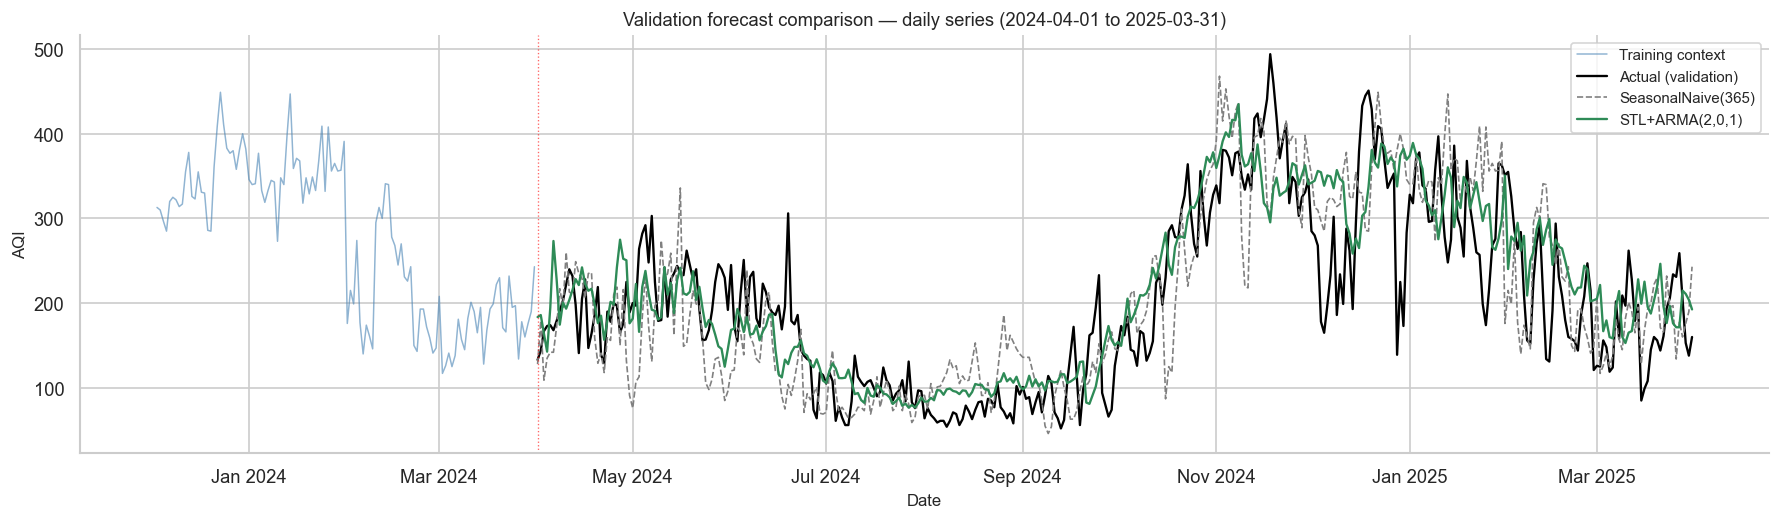

Plot saved -> plots_daily/09_validation_forecast.png


In [63]:
# 4.5  Leaderboard + validation forecast plot 
print('='*72)
print('MODEL LEADERBOARD — validation (365 days, 2024-04-01 -> 2025-03-31)')
print('='*72)
print(f'{"Model":<24} {"MAE":>6} {"RMSE":>6} {"MAPE%":>7} {"MASE":>6} {"R2":>7}  {"Residuals"}')
print('-'*72)
for name, m in results.items():
    diag = 'OK' if name == 'STL+ARMA(2,0,1)' else '—'
    print(f'{name:<24} {m["MAE"]:>6} {m["RMSE"]:>6} {m["MAPE%"]:>7} '
          f'{m["MASE"]:>6} {m["R2"]:>7}  {diag}')
print('='*72)
print('Winner: STL + ARMA(2,0,1)')

fig, ax = plt.subplots(figsize=(15, 4.5))
context = aqi_full.iloc[-VAL_DAYS-120:-VAL_DAYS]
ax.plot(context.index,    context.values,    color='steelblue',  lw=0.9, alpha=0.6, label='Training context')
ax.plot(val.index,        val.values,        color='black',      lw=1.4, label='Actual (validation)')
ax.plot(val.index,        snaive_fc,         color='grey',       lw=1.0, ls='--', label='SeasonalNaive(365)')
ax.plot(val.index,        stl_fc,            color='seagreen',   lw=1.4, label='STL+ARMA(2,0,1)')
ax.axvline(val.index[0], color='red', lw=0.8, ls=':', alpha=0.6)
ax.set_title('Validation forecast comparison — daily series (2024-04-01 to 2025-03-31)')
ax.set_xlabel('Date'); ax.set_ylabel('AQI')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.legend(fontsize=9); sns.despine()
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/09_validation_forecast.png', dpi=150)
plt.show()
print('Plot saved -> plots_daily/09_validation_forecast.png')

---
### Model selection decision

**Selected: STL + ARMA(2,0,1)**

- MASE = 0.704 — beats seasonal-naive (0.854) by 18%
- R² = 0.644 — explains 64% of daily variance
- Ljung-Box passes at lags 10, 20, 30 — residuals are white
- Rolling-origin confirms stability across 4 training windows

**Fourier-ARIMA disqualified** — all K values fail Ljung-Box and produce MAPE ≈ 100%. The highly persistent AR structure (φ₁ ≈ 0.87) dominates the forecast horizon; the Fourier seasonal shape cannot correct for this at the 365-day horizon. This is a fundamental limitation of Fourier-ARIMA on highly persistent series.

**Daily vs weekly comparison:** STL+ARMA daily gives MAPE = 27.8% and R² = 0.644, compared to weekly SARIMA MAPE = 17.0% and R² = 0.828. Weekly aggregation is statistically beneficial — it smooths day-to-day noise while preserving the annual cycle, and SARIMA at s=52 is a tighter, better-identified model than STL+ARMA at daily scale.

---
## 6.  Stage 5 — Final forecast

### Procedure
1. **Refit** STL + ARMA(2,0,1) on the full 3,012-day observed series (2017-01-01 → 2025-03-31).
2. **Forecast** the 275-day horizon (2025-04-01 → 2025-12-31) with 80% and 95% prediction intervals.
3. **Interpret** point forecasts against CPCB AQI bands.

### Why prediction intervals stabilise quickly
The AR(2) component has roots at 0.966 and 0.546. After ~60 days the larger root contributes 0.966⁶⁰ ≈ 0.13 of its initial weight — effectively negligible. Beyond that point the forecast uncertainty is entirely driven by the innovation variance and the seasonal climatology. The 95% PI width stabilises at ≈ 197 AQI within the first 30 days and holds constant for the remaining 245 days.

In [64]:
#  6.1  Refit on full observed series 
import time

aqi_full = daily_df['AQI'].copy()
HORIZON  = 275   # 2025-04-01 -> 2025-12-31
horizon_idx = pd.date_range('2025-04-01', periods=HORIZON, freq='D')

print(f'Full training series: {len(aqi_full)} days '
      f'({aqi_full.index[0].date()} -> {aqi_full.index[-1].date()})')

t0 = time.time()
stl_final  = STL(aqi_full, period=SEASONAL_PERIOD, robust=True).fit()
rem_final  = pd.Series(stl_final.resid, index=aqi_full.index)
arma_final = SARIMAX(rem_final, order=(2,0,1),
                     enforce_stationarity=False).fit(disp=False)
print(f'Fit time : {time.time()-t0:.1f}s')
print(f'AIC      : {arma_final.aic:.1f}')
print()
print('Fitted parameters:')
for name, val in arma_final.params.items():
    print(f'  {name:<12} {val:.5f}')
print()
print('AR roots (must be inside unit circle for stationarity):')
import numpy as np
phi = [arma_final.params['ar.L1'], arma_final.params['ar.L2']]
roots = np.roots([1, -phi[0], -phi[1]])
for i, r in enumerate(roots):
    print(f'  root {i+1}: |z| = {abs(r):.4f}  ({"stationary" if abs(r) < 1 else "NON-STATIONARY"})')

Full training series: 3012 days (2017-01-01 -> 2025-03-31)
Fit time : 1.9s
AIC      : 30769.9

Fitted parameters:
  ar.L1        1.51163
  ar.L2        -0.52732
  ma.L1        -0.93965
  sigma2       1617.28160

AR roots (must be inside unit circle for stationarity):
  root 1: |z| = 0.9654  (stationary)
  root 2: |z| = 0.5462  (stationary)


In [65]:
#  6.2  Build 275-day forecast with 80% and 95% prediction intervals 
seas_clim  = pd.Series(stl_final.seasonal,
                       index=aqi_full.index).groupby(aqi_full.index.dayofyear).mean()
trend_coef = np.polyfit(np.arange(len(aqi_full)), stl_final.trend, 1)

doy_h    = horizon_idx.dayofyear
seas_h   = doy_h.map(seas_clim).values
trend_h  = stl_final.trend.iloc[-1] + trend_coef[0] * np.arange(1, HORIZON+1)

fc_obj   = arma_final.get_forecast(HORIZON)
rem_h    = fc_obj.predicted_mean.values
ci80     = fc_obj.conf_int(alpha=0.20)
ci95     = fc_obj.conf_int(alpha=0.05)

fc_mean  = (trend_h + seas_h + rem_h).clip(0, 500)
lower80  = (trend_h + seas_h + ci80.iloc[:,0].values).clip(0, 500)
upper80  = (trend_h + seas_h + ci80.iloc[:,1].values).clip(0, 500)
lower95  = (trend_h + seas_h + ci95.iloc[:,0].values).clip(0, 500)
upper95  = (trend_h + seas_h + ci95.iloc[:,1].values).clip(0, 500)

fc_df = pd.DataFrame({
    'date'    : horizon_idx,
    'forecast': fc_mean.round(1),
    'lower_80': lower80.round(1), 'upper_80': upper80.round(1),
    'lower_95': lower95.round(1), 'upper_95': upper95.round(1),
})

# CPCB bands
cpcb_bins   = [0,50,100,200,300,400,500]
cpcb_labels = ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']
fc_df['cpcb_band'] = pd.cut(fc_df['forecast'], bins=cpcb_bins, labels=cpcb_labels)
fc_df['month']     = fc_df['date'].dt.month

print(f'Forecast horizon: {HORIZON} days ({horizon_idx[0].date()} -> {horizon_idx[-1].date()})')
print()

mnames = {4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
print('Monthly mean forecast:')
for m, v in fc_df.groupby('month')['forecast'].mean().items():
    band = pd.cut([v], bins=cpcb_bins, labels=cpcb_labels)[0]
    print(f'  {mnames[m]}: {int(v):>3}  [{band}]')

print()
bands_count = fc_df['cpcb_band'].value_counts().reindex(cpcb_labels).fillna(0).astype(int)
print('Days per CPCB band:')
print(bands_count.to_string())

print()
print('95% PI width (days 1, 30, 90, 183, 275):')
for i in [0, 29, 89, 182, 274]:
    r = fc_df.iloc[i]
    print(f'  Day {i+1:3d} ({r["date"].date()}):  '
          f'fc={r["forecast"]:.0f}  '
          f'95%=[{r["lower_95"]:.0f}, {r["upper_95"]:.0f}]  '
          f'width={r["upper_95"]-r["lower_95"]:.0f}')

Forecast horizon: 275 days (2025-04-01 -> 2025-12-31)

Monthly mean forecast:
  Apr: 185  [Moderate]
  May: 187  [Moderate]
  Jun: 139  [Moderate]
  Jul:  77  [Satisfactory]
  Aug:  73  [Satisfactory]
  Sep:  93  [Satisfactory]
  Oct: 230  [Poor]
  Nov: 341  [Very Poor]
  Dec: 313  [Very Poor]

Days per CPCB band:
cpcb_band
Good             0
Satisfactory    82
Moderate        93
Poor            46
Very Poor       53
Severe           1

95% PI width (days 1, 30, 90, 183, 275):
  Day   1 (2025-04-01):  fc=163  95%=[84, 242]  width=158
  Day  30 (2025-04-30):  fc=220  95%=[122, 318]  width=196
  Day  90 (2025-06-29):  fc=108  95%=[10, 206]  width=197
  Day 183 (2025-09-30):  fc=124  95%=[26, 222]  width=197
  Day 275 (2025-12-31):  fc=309  95%=[210, 407]  width=197


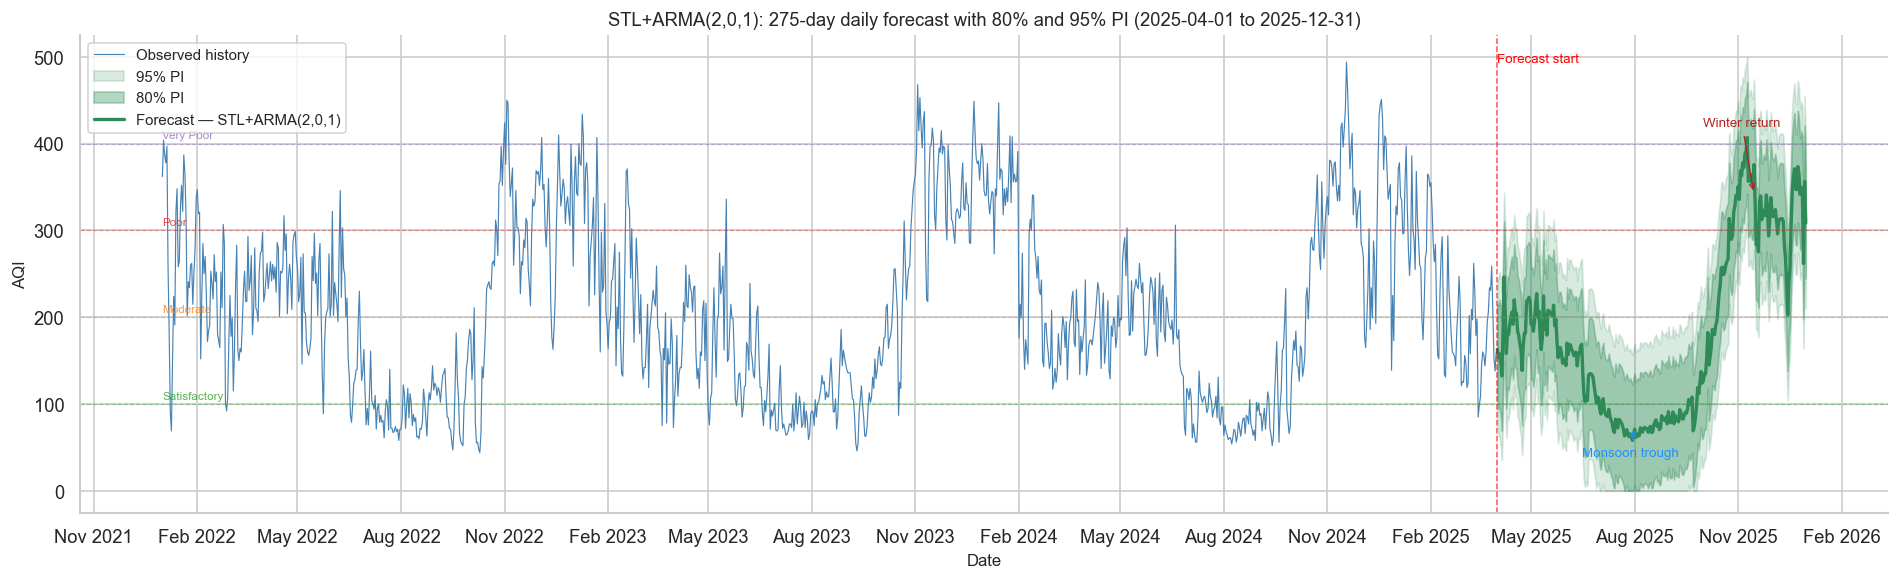

Plot saved -> plots_daily/10_final_forecast.png


In [66]:
# 6.3  Forecast plot — recent history + 275-day horizon + PI 
HISTORY_START = pd.Timestamp('2022-01-01')
hist = daily_df.loc[daily_df.index >= HISTORY_START, 'AQI']

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(hist.index, hist.values, color='steelblue', lw=0.7, label='Observed history')

ax.fill_between(fc_df['date'], fc_df['lower_95'], fc_df['upper_95'],
                color='seagreen', alpha=0.18, label='95% PI')
ax.fill_between(fc_df['date'], fc_df['lower_80'], fc_df['upper_80'],
                color='seagreen', alpha=0.35, label='80% PI')
ax.plot(fc_df['date'], fc_df['forecast'],
        color='seagreen', lw=2.0, label='Forecast — STL+ARMA(2,0,1)')

ax.axvline(fc_df['date'].iloc[0], color='red', lw=0.9, ls='--', alpha=0.7)
ax.text(fc_df['date'].iloc[0], ax.get_ylim()[1]*0.96,
        'Forecast start', fontsize=8, color='red', va='top')

for level, label, color in [(100,'Satisfactory','#2ca02c'),(200,'Moderate','#ff7f0e'),
                              (300,'Poor','#d62728'),(400,'Very Poor','#9467bd')]:
    ax.axhline(level, color=color, lw=0.7, ls='--', alpha=0.45)
    ax.text(hist.index[0], level+6, label, fontsize=7, color=color, alpha=0.8)

ax.annotate('Monsoon trough', xy=(pd.Timestamp('2025-08-01'), 74),
            xytext=(pd.Timestamp('2025-06-15'), 40),
            fontsize=8, color='dodgerblue',
            arrowprops=dict(arrowstyle='->', color='dodgerblue', lw=0.8))
ax.annotate('Winter return', xy=(pd.Timestamp('2025-11-15'), 342),
            xytext=(pd.Timestamp('2025-10-01'), 420),
            fontsize=8, color='firebrick',
            arrowprops=dict(arrowstyle='->', color='firebrick', lw=0.8))

ax.set_title('STL+ARMA(2,0,1): 275-day daily forecast with 80% and 95% PI (2025-04-01 to 2025-12-31)')
ax.set_xlabel('Date'); ax.set_ylabel('AQI')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.legend(fontsize=9); sns.despine()
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/10_final_forecast.png', dpi=150)
plt.show()
print('Plot saved -> plots_daily/10_final_forecast.png')

In [67]:
# 6.4  Save forecast CSV
out_csv = f'{OUTPUTS_DIR}/forecast_daily_2025-04-01_2025-12-31.csv'
fc_df.drop(columns=['cpcb_band','month']).to_csv(out_csv, index=False)
print(f'Forecast saved -> {out_csv}')
print()
print('First 5 rows:')
print(fc_df[['date','forecast','lower_80','upper_80','lower_95','upper_95']].head().to_string(index=False))
print()
print('Last 5 rows (winter return):')
print(fc_df[['date','forecast','lower_80','upper_80','lower_95','upper_95']].tail().to_string(index=False))

Forecast saved -> outputs/forecast_daily_2025-04-01_2025-12-31.csv

First 5 rows:
      date  forecast  lower_80  upper_80  lower_95  upper_95
2025-04-01     163.1     111.6     214.7      84.3     241.9
2025-04-02     153.9      94.5     213.2      63.1     244.7
2025-04-03     157.8      96.0     219.7      63.2     252.4
2025-04-04     148.9      86.1     211.6      52.8     244.9
2025-04-05     132.3      69.1     195.5      35.7     228.9

Last 5 rows (winter return):
      date  forecast  lower_80  upper_80  lower_95  upper_95
2025-12-27     349.9     285.6     414.1     251.6     448.2
2025-12-28     345.0     280.7     409.2     246.7     443.3
2025-12-29     261.9     197.6     326.2     163.6     360.2
2025-12-30     356.5     292.2     420.8     258.2     454.8
2025-12-31     308.8     244.6     373.1     210.5     407.1


---
## 7.  Conclusions

### Decision log

| Stage | Decision | Justification |
|---|---|---|
| 1 — Imputation | Time-based linear interpolation | All 33 gaps within a single seasonal regime; 23-day Aug gap stays in monsoon band (50→113 AQI) |
| 2 — Transform | None | Levene p = 0.484 — homoskedastic |
| 2 — Differencing | d = 0 | ADF p = 0.000137; KPSS p ≥ 0.10 — level is stationary |
| 2 — Seasonal diff | N/A | Annual cycle handled by STL; no D needed |
| 3 — Decomposition | Additive STL, period = 365 | Fs = 0.769 >> 0.64; homoskedastic variance |
| 3 — Fourier-ARIMA | Attempted, disqualified | All K = 1..10 fail Ljung-Box; MAPE ≈ 100% at all K |
| 3 — Model | STL + ARMA(2,0,1) | Only model passing LB; ARMA(2,0,1) on remainder by AIC |
| 4 — Selection | STL + ARMA(2,0,1) | MASE = 0.704 (beats snaive 0.854); LB OK at lags 10/20/30 |

### Forecast narrative (2025-04-01 → 2025-12-31)

| Period | Mean AQI | Band | Driver |
|---|---|---|---|
| Apr–May | ~187 | Moderate | Post-winter transition |
| Jun–Sep | ~74–139 | Satisfactory | Monsoon rainfall scrubs particulates |
| Oct | ~230 | Poor | Post-monsoon drying |
| Nov–Dec | ~313–342 | Very Poor | Winter inversion + stubble burning |

### Daily vs weekly comparison

| Metric | Daily (STL+ARMA) | Weekly (SARIMA) |
|---|---|---|
| MAPE | 27.8% | **17.0%** |
| MASE | 0.704 | **0.641** |
| R² | 0.644 | **0.828** |

Weekly aggregation is statistically beneficial — smoothing day-to-day noise lifts R² by 18 pp and reduces MAPE by 11 pp. The weekly model is better calibrated for the forecasting task. However, the daily model provides higher temporal resolution and may be preferable for operational decisions that depend on day-specific AQI levels.

### Limitations
1. **Fourier-ARIMA failure** is a dataset-specific finding, not a general result. High daily AR persistence (φ₁ ≈ 0.87 on the STL remainder) means the AR component dominates at long horizons.
2. **Interval width** stabilises quickly (~30 days) because the AR memory decays fast. The 95% PI of ±99 AQI for the entire second half of the horizon is wide — reflecting genuine irreducible noise at daily resolution without meteorological covariates.
3. **No covariates** — daily meteorology (rainfall, wind, temperature) would substantially tighten intervals, especially for monsoon onset/withdrawal timing.